 # Лабораторна робота 11

 ## Тема: Розпізнавання обличчя людей на фотографії



 **Мета:** Навчитися верифікації людини на фотографії за допомогою попередньо навченої згорткової нейронної мережі та бібліотеки dlib.

 ## 1. Підготовка (Setup)



 ### Встановлення dlib (для Google Colab)



 Для встановлення dlib може знадобитися встановлення системних залежностей, таких як `cmake`.

In [1]:
# Встановлення необхідних бібліотек у Colab/Anaconda
# У Colab це може зайняти кілька хвилин
%pip install dlib-bin numpy scikit-image

# Завантаження попередньо навчених моделей dlib
# Ці файли мають бути розпаковані та знаходитися у робочій директорії
import os

model_dir = "." # Каталог для моделей

# Модель для виділення 68 ключових точок обличчя
url_landmarks = "http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2"
filename_landmarks = os.path.join(model_dir, "shape_predictor_68_face_landmarks.dat")

# Модель для виділення дескрипторів обличчя (ResNet)
url_face_rec = "http://dlib.net/files/dlib_face_recognition_resnet_model_v1.dat.bz2"
filename_face_rec = os.path.join(model_dir, "dlib_face_recognition_resnet_model_v1.dat")

if not os.path.exists(filename_landmarks):
    print(f"Завантаження {os.path.basename(filename_landmarks)}.bz2...")
    !curl -L -o {filename_landmarks}.bz2 {url_landmarks}
    !bzip2 -dk {filename_landmarks}.bz2
    
if not os.path.exists(filename_face_rec):
    print(f"Завантаження {os.path.basename(filename_face_rec)}.bz2...")
    !curl -L -o {filename_face_rec}.bz2 {url_face_rec}
    !bzip2 -dk {filename_face_rec}.bz2
    
print("Підготовка завершена.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 15.4 MB/s eta 0:00:00a 0:00:01
Завантаження shape_predictor_68_face_landmarks.dat.bz2...
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   272  100   272    0     0   1685      0 --:--:-- --:--:-- --:--:--  1679
100 61.0M  100 61.0M    0     0  29.8M      0  0:00:02  0:00:02 --:--:-- 57.3M
Завантаження dlib_face_recognition_resnet_model_v1.dat.bz2...
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   276  100   276    0     0   1884      0 --:--:-- --:--:-- --:--:--  1890
100 20.4M  100 20.4M    0     0  12.9M      0  0:00:01  0:00:01 --:--:-- 21.3M
Підготовка завершена.


 ## 2. Імпорт модулів та Завантаження моделей



 Імпортуємо dlib та необхідні функції для роботи з зображеннями.

In [2]:
import dlib
import numpy as np
from skimage import io
from scipy.spatial.distance import euclidean
import matplotlib.pyplot as plt

# Створюємо детектор обличчя (HOG-детектор)
face_detector = dlib.get_frontal_face_detector()

# Створюємо модель для визначення 68 ключових точок обличчя
shape_predictor = dlib.shape_predictor(filename_landmarks)

# Створюємо модель для вилучення дескрипторів обличчя (128-D вектор)
face_recognizer = dlib.face_recognition_model_v1(filename_face_rec)

print("Модулі імпортовані та моделі завантажені.")


Модулі імпортовані та моделі завантажені.


 ## 3. Обробка першого фото



 Завантажуємо першу фотографію, знаходимо обличчя та вилучаємо його дескриптор.



 **Примітка:** Замініть 'photo1.jpg' на реальний шлях до вашого файлу.

In [19]:
# Завантаження тестових зображень

image_filenames = ["photo1.png", "photo2.png"]
for i in image_filenames:
    !wget -nc https://raw.githubusercontent.com/oleksandr-holan/deep-learning/refs/heads/master/lab11/test_images/{i} -P ./uploaded_files


--2026-01-08 17:52:45--  https://raw.githubusercontent.com/oleksandr-holan/deep-learning/refs/heads/master/lab11/test_images/photo1.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1518687 (1.4M) [image/png]
Saving to: ‘./uploaded_files/photo1.png’

photo1.png          100%[===================>]   1.45M  --.-KB/s    in 0.03s   

2026-01-08 17:52:45 (44.5 MB/s) - ‘./uploaded_files/photo1.png’ saved [1518687/1518687]

--2026-01-08 17:52:45--  https://raw.githubusercontent.com/oleksandr-holan/deep-learning/refs/heads/master/lab11/test_images/photo2.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:44

In [18]:
!rm -rf ./uploaded_files/

Фотографія 1 завантажена.
Зображення конвертовано з RGBA у RGB.
Масив зображення зроблено C-неперервним.

Дескриптор обличчя 1 (перші 5 елементів):
[-0.15235487  0.18319339  0.06693476 -0.03186233 -0.07341971]
Знайдено облич: 1


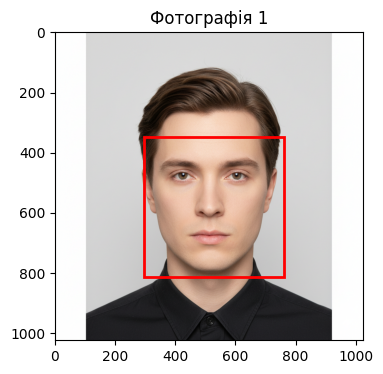

In [14]:
# Завантаження першої фотографії
try:
    img1 = io.imread('./uploaded_files/photo1.png')
    print("Фотографія 1 завантажена.")
except FileNotFoundError:
    print("ПОМИЛКА: Файл 'photo1.png' не знайдено. Будь ласка, завантажте його.")
    # Створюємо фіктивне зображення для запобігання помилці
    img1 = np.zeros((100, 100, 3), dtype=np.uint8)

if img1.ndim == 3 and img1.shape[2] == 4:
    # Якщо 4 канали (RGBA), обрізаємо до RGB (3 канали)
    img1 = img1[:, :, :3]
    print("Зображення конвертовано з RGBA у RGB.")
    
if img1.dtype != np.uint8:
    # Конвертуємо до 8-бітного формату, якщо інший
    # Примітка: якщо це 16-бітне зображення, може знадобитися додаткова нормалізація, 
    # але для стандартних JPEG/PNG достатньо конвертації типу:
    img1 = img1.astype(np.uint8)
    print("Тип даних зображення конвертовано у np.uint8.") 

if not img1.flags['C_CONTIGUOUS']:
    img1 = np.ascontiguousarray(img1)
    print("Масив зображення зроблено C-неперервним.")

# Знаходимо обличчя на фотографії 1
detections1 = face_detector(img1, 1)

if len(detections1) == 0:
    print("Обличчя не знайдено на фотографії 1.")
    descriptor1 = None
else:
    # Використовуємо перше знайдене обличчя
    face_rect1 = detections1[0]
    
    # Виділяємо ключові точки
    shape1 = shape_predictor(img1, face_rect1)
    
    # Вилучаємо дескриптор обличчя (128-D вектор)
    descriptor1 = face_recognizer.compute_face_descriptor(img1, shape1)
    
    # Друкуємо дескриптор (перетворюємо у numpy масив для зручності друку)
    print("\nДескриптор обличчя 1 (перші 5 елементів):")
    print(np.array(descriptor1)[:5])
    print(f"Знайдено облич: {len(detections1)}")
    
    # Відображення фотографії з рамкою (опціонально, використовуємо matplotlib для Colab)
    plt.figure(figsize=(8, 4))
    plt.imshow(img1)
    plt.title("Фотографія 1")
    # Малюємо прямокутник навколо обличчя
    plt.gca().add_patch(plt.Rectangle((face_rect1.left(), face_rect1.top()), 
                                      face_rect1.width(), face_rect1.height(),
                                      edgecolor='r', facecolor='none', lw=2))
    plt.show()



 ## Обробка другого фото

Фотографія 2 завантажена.
Зображення конвертовано з RGBA у RGB.
Масив зображення зроблено C-неперервним.

Дескриптор обличчя 2 (перші 5 елементів):
[-0.11901634  0.12388569  0.06133417 -0.0276773  -0.04554731]
Знайдено облич: 1


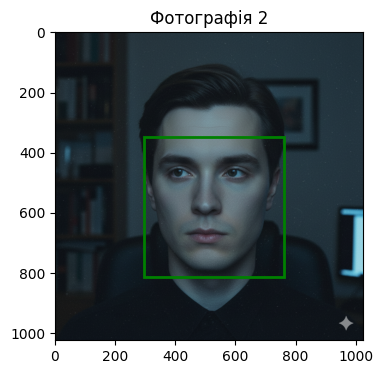

In [20]:
try:
    img2 = io.imread('./uploaded_files/photo2.png')
    print("Фотографія 2 завантажена.")
except FileNotFoundError:
    print("ПОМИЛКА: Файл 'photo2.png' не знайдено. Будь ласка, завантажте його.")
    exit(1)

if img2.ndim == 3 and img2.shape[2] == 4:
    img2 = img2[:, :, :3]
    print("Зображення конвертовано з RGBA у RGB.")

if img2.dtype != np.uint8:
    img2 = img2.astype(np.uint8)
    print("Тип даних зображення конвертовано у np.uint8.")

if not img2.flags["C_CONTIGUOUS"]:
    img2 = np.ascontiguousarray(img2)
    print("Масив зображення зроблено C-неперервним.")

detections2 = face_detector(img2, 1)

if len(detections2) == 0:
    print("Обличчя не знайдено на фотографії 2.")
    descriptor2 = None
else:
    face_rect2 = detections2[0]
    
    shape2 = shape_predictor(img2, face_rect2)
    
    descriptor2 = face_recognizer.compute_face_descriptor(img2, shape2)
    
    print("\nДескриптор обличчя 2 (перші 5 елементів):")
    print(np.array(descriptor2)[:5])
    print(f"Знайдено облич: {len(detections2)}")
    
    plt.figure(figsize=(8, 4))
    plt.imshow(img2)
    plt.title("Фотографія 2")
    plt.gca().add_patch(plt.Rectangle((face_rect2.left(), face_rect2.top()), 
                                      face_rect2.width(), face_rect2.height(),
                                      edgecolor='g', facecolor='none', lw=2))
    plt.show()


 ## 5. Порівняння дескрипторів та верифікація



 Обчислюємо евклідову відстань між дескрипторами. Згідно з рекомендацією **dlib**, поріг для верифікації (одна і та ж особа) становить **0,6**.

In [21]:
if descriptor1 is not None and descriptor2 is not None:
    # Обчислення евклідової відстані
    distance = euclidean(np.array(descriptor1), np.array(descriptor2))
    
    # Поріг
    VERIFICATION_THRESHOLD = 0.6
    
    print("\n--- Результати Верифікації ---")
    print(f"Евклідова відстань між дескрипторами: {distance:.4f}")
    print(f"Поріг dlib для верифікації: {VERIFICATION_THRESHOLD}")
    
    # Прийняття рішення
    if distance < VERIFICATION_THRESHOLD:
        print("ВЕРДИКТ: Відстань МЕНШЕ порогу. Ймовірно, на фотографіях ЗОБРАЖЕНА ОДНА ЛЮДИНА.")
    else:
        print("ВЕРДИКТ: Відстань БІЛЬШЕ порогу. Ймовірно, на фотографіях ЗОБРАЖЕНІ РІЗНІ ЛЮДИ.")
else:
    print("\nНеможливо провести порівняння, оскільки на одній або обох фотографіях не знайдено обличчя.")



--- Результати Верифікації ---
Евклідова відстань між дескрипторами: 0.3339
Поріг dlib для верифікації: 0.6
ВЕРДИКТ: Відстань МЕНШЕ порогу. Ймовірно, на фотографіях ЗОБРАЖЕНА ОДНА ЛЮДИНА.


 ## 6. Експериментальні дослідження та висновки



 **Завдання для самостійного виконання (опис у звіті):**



 1.  Проведіть експерименти, порівнюючи фотографії однієї людини та різних людей.

 2.  Спробуйте знайти фотографії дуже схожих, але різних осіб, і порівняти їх.

 3.  Зробіть власні фотографії з різних ракурсів, з різним поворотом/нахилом голови і протестуйте модель.

     *   **Питання для аналізу:** Чи збільшується евклідова відстань? Чи правильно модель визначає, що це одна й та сама людина?

 4.  Знайдіть фотографію однієї людини різного віку або зі значними змінами зачіски/зовнішності (борода, вуса, окуляри).

     *   **Питання для аналізу:** Чи правильно визначає модель, що це одна й та сама людина?

 5.  (Додатково) Спробуйте поекспериментувати з бібліотекою [OpenFace](https://cmusatyalab.github.io/openface/).



 **Висновок:** Сформулюйте висновки до лабораторної роботи, аналізуючи отримані результати, особливо поріг верифікації та вплив зовнішніх факторів (ракурс, вік, зачіска) на евклідову відстань.

In [ ]:
image_filenames = ["boy1.png", "boy2.png", "girl1.png", "man1.png", "margot_robbie1.jpg", "margot_robbie2.webp", "margot_robbie3.webp", "twin1.webp", "twin2.webp"]
for i in image_filenames:
    !wget -nc https://raw.githubusercontent.com/oleksandr-holan/deep-learning/refs/heads/master/lab11/test_images/{i} -P ./uploaded_files


 ## 6. Експериментальні дослідження



 Завантажимо додаткові тестові зображення та проведемо серію експериментів для перевірки стійкості алгоритму.

In [46]:
import os

image_filenames = [
    "boy1.png",
    "boy2.png",  # Різні хлопці
    "girl1.png",  # Інша людина (дівчинка)
    "man1.png",  # Інша людина (чоловік)
    "margot_robbie1.jpg",  # Марго Роббі
    "margot_robbie2.webp",  # Марго Роббі
    "margot_robbie3.webp",  # Марго Роббі
    "twin1.webp",
    "twin2.webp",  # Близнюки (схожі, але різні люди)
    "me1.jpg",
    "me2.jpg",
    "me3.jpg",
    "me4.jpg",
    "me5.jpg",
    "me6.jpg",
    "me7.jpg",
    "me8.jpg",
    "me9.jpg",
    "me10.jpg",
    "me11.jpg",
    "me12.jpg"
]

save_dir = "./uploaded_files"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

print("Завантаження файлів...")
for i in image_filenames:
    url = f"https://raw.githubusercontent.com/oleksandr-holan/deep-learning/refs/heads/master/lab11/test_images/{i}"
    !wget -q --show-progress -nc {url} -P {save_dir}

print("Завантаження завершено.")


Завантаження файлів...
me12.jpg            100%[===================>] 670.11K  --.-KB/s    in 0.03s   
Завантаження завершено.


 ### Функція для автоматичного порівняння



 Створимо функцію `compare_images`, яка приймає шляхи до двох файлів, знаходить обличчя, будує дескриптори, обчислює відстань та візуалізує результат.

In [47]:
def get_face_data(filepath):
    """Завантажує зображення та повертає (img, descriptor, face_rect)"""
    try:
        img = io.imread(filepath)
    except Exception as e:
        print(f"Помилка читання файлу {filepath}: {e}")
        return None, None, None

    # Попередня обробка (RGB, uint8)
    if img.ndim == 3 and img.shape[2] == 4:
        img = img[:, :, :3]
    if img.dtype != np.uint8:
        img = img.astype(np.uint8)
    if not img.flags['C_CONTIGUOUS']:
        img = np.ascontiguousarray(img)

    # Детекція
    detections = face_detector(img, 1)
    
    if not detections:
        return img, None, None
    
    # Беремо перше (найбільше) обличчя
    face_rect = detections[0]
    shape = shape_predictor(img, face_rect)
    descriptor = face_recognizer.compute_face_descriptor(img, shape)
    
    return img, np.array(descriptor), face_rect

def compare_images(file1, file2, title_text="Порівняння"):
    """Основна функція для порівняння та візуалізації"""
    path1 = os.path.join("./uploaded_files", file1)
    path2 = os.path.join("./uploaded_files", file2)
    
    img1, desc1, rect1 = get_face_data(path1)
    img2, desc2, rect2 = get_face_data(path2)
    
    if desc2 is None:
        print(f"ПОМИЛКА: Не вдалося знайти обличчя на зображенні {file2}.")
        return
    if desc1 is None:
        print(f"ПОМИЛКА: Не вдалося знайти обличчя на зображенні {file1}.")
        return


    # Обчислення відстані
    distance = euclidean(desc1, desc2)
    threshold = 0.6
    is_same = distance < threshold
    
    # Візуалізація
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    # Фото 1
    axes[0].imshow(img1)
    axes[0].set_title(file1)
    if rect1:
        rect = plt.Rectangle((rect1.left(), rect1.top()), rect1.width(), rect1.height(),
                             edgecolor='blue', facecolor='none', lw=2)
        axes[0].add_patch(rect)
    axes[0].axis('off')

    # Фото 2
    axes[1].imshow(img2)
    axes[1].set_title(file2)
    if rect2:
        rect = plt.Rectangle((rect2.left(), rect2.top()), rect2.width(), rect2.height(),
                             edgecolor='blue', facecolor='none', lw=2)
        axes[1].add_patch(rect)
    axes[1].axis('off')
    
    # Результат по центру
    verdict_color = "green" if is_same else "red"
    verdict_text = "ОДНА ЛЮДИНА" if is_same else "РІЗНІ ЛЮДИ"
    
    plt.suptitle(f"{title_text}\nВідстань: {distance:.4f} (Поріг: {threshold})\nВердикт: {verdict_text}", 
                 fontsize=14, color=verdict_color, y=1.05)
    plt.tight_layout()
    plt.show()


 ### Експеримент 1: Різні люди

 Порівняємо чоловіка (`man1`) з дівчинкою (`girl1`). Очікуємо відстань > 0.6.

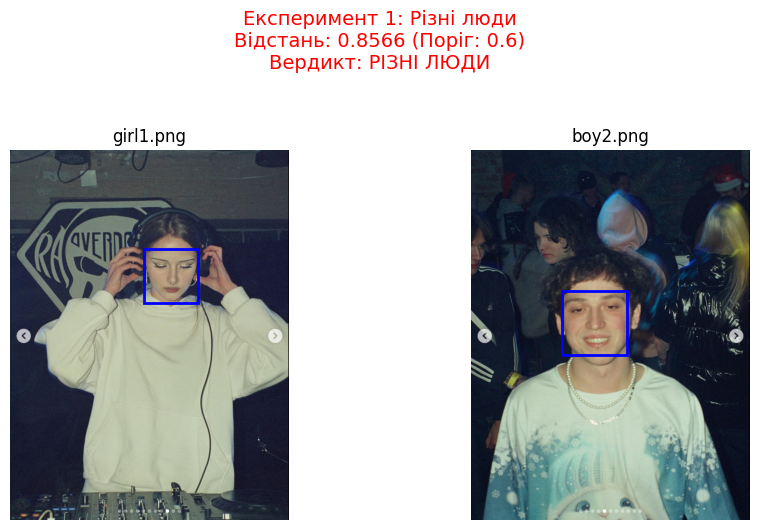

In [45]:
compare_images("girl1.png", "boy2.png", title_text="Експеримент 1: Різні люди")

# compare_images("man1.png", "girl1.png", title_text="Експеримент 2.2: Різні статі/вік")

 ### Експеримент 2: Дуже схожі люди

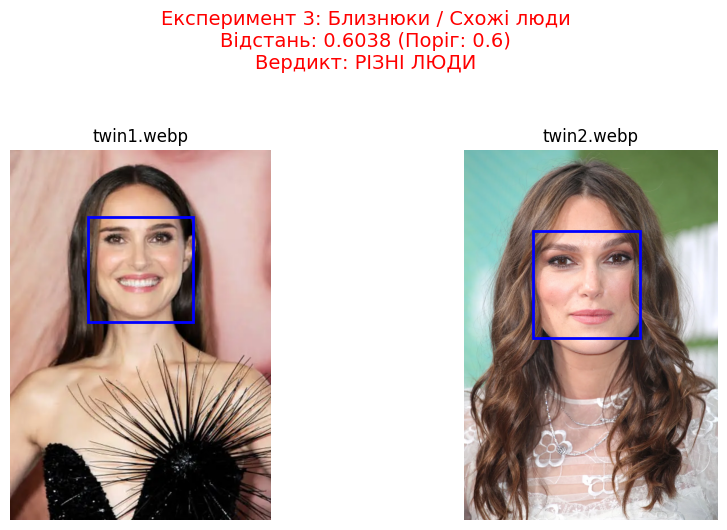

In [ ]:
compare_images("twin1.webp", "twin2.webp", title_text="Експеримент 2: Схожі люди")


 ### Експеримент 3: Вплив ракурсу та стилю (Марго Роббі)

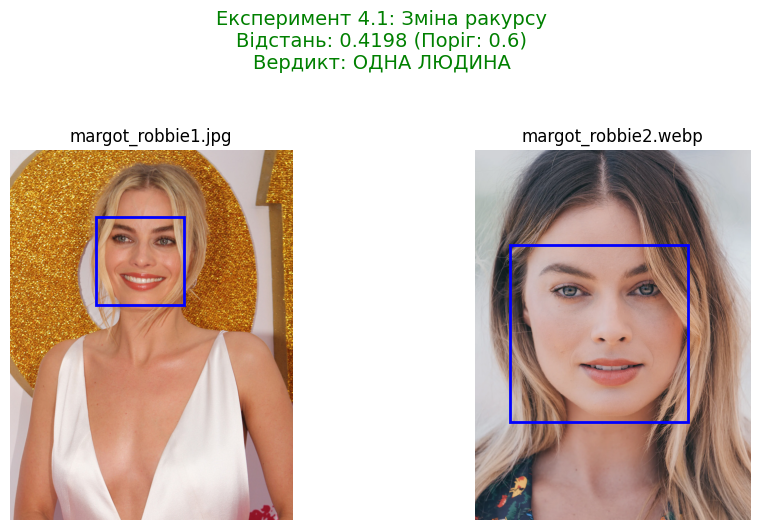

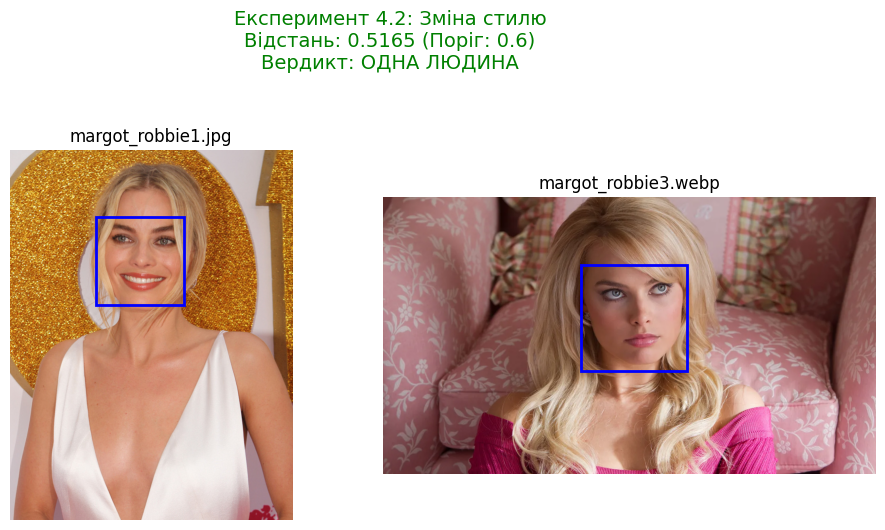

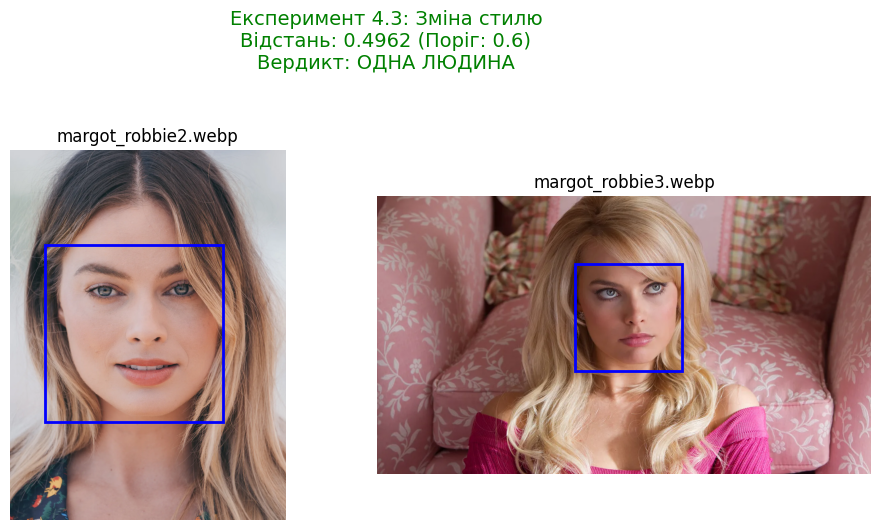

In [35]:
# Порівняння 1 та 2 (різні ракурси)
compare_images("margot_robbie1.jpg", "margot_robbie2.webp", title_text="Експеримент 4.1: Зміна ракурсу")

# Порівняння 1 та 3 (зміна стилю/емоції)
compare_images("margot_robbie1.jpg", "margot_robbie3.webp", title_text="Експеримент 4.2: Зміна стилю")

compare_images(
    "margot_robbie2.webp",
    "margot_robbie3.webp",
    title_text="Експеримент 4.3: Зміна стилю",
)

### Експеримент 4: Мої фото

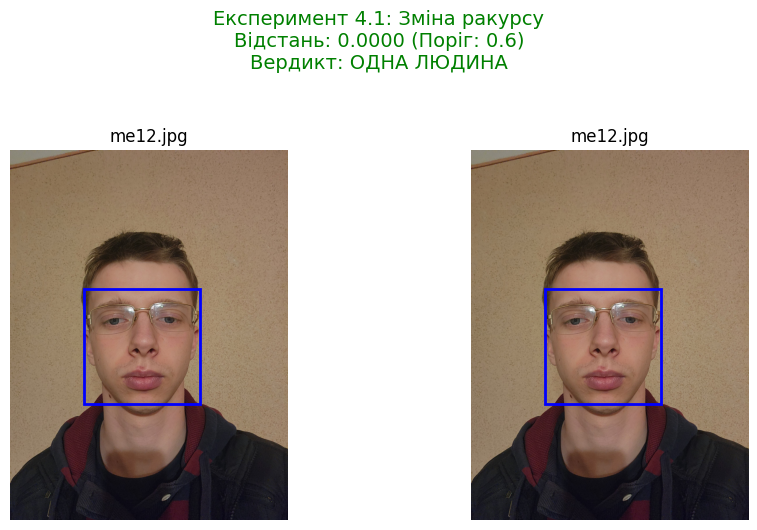

In [48]:
# Порівняння 1 та 2 (різні ракурси)
# compare_images(
#     "me1.jpg",
#     "me2.jpg",
#     title_text="Експеримент 4.1: Зміна ракурсу",
# )

# # Порівняння 1 та 3 (зміна стилю/емоції)
# compare_images(
#     "me1.jpg",
#     "me3.jpg",
#     title_text="Експеримент 4.2: Зміна стилю",
# )

# compare_images(
#     "me2.jpg",
#     "me3.jpg",
#     title_text="Експеримент 4.3: Зміна стилю",
# )

# compare_images(
#     "me1.jpg",
#     "me1.jpg",
#     title_text="Експеримент 4.1: Зміна ракурсу",
# )

# compare_images(
#     "me1.jpg",
#     "me5.jpg",
#     title_text="Експеримент 4.1: Зміна ракурсу",
# )

# compare_images(
#     "me1.jpg",
#     "me6.jpg",
#     title_text="Експеримент 4.1: Зміна ракурсу",
# )

# compare_images(
#     "me1.jpg",
#     "me7.jpg",
#     title_text="Експеримент 4.1: Зміна ракурсу",
# )

# compare_images(
#     "me1.jpg",
#     "me8.jpg",
#     title_text="Експеримент 4.1: Зміна ракурсу",
# )

# compare_images(
#     "me1.jpg",
#     "me9.jpg",
#     title_text="Експеримент 4.1: Зміна ракурсу",
# )

# compare_images(
#     "me1.jpg",
#     "me10.jpg",
#     title_text="Експеримент 4.1: Зміна ракурсу",
# )

compare_images(
    "me12.jpg",
    "me12.jpg",
    title_text="Експеримент 4.1: Зміна ракурсу",
)
